In [27]:
# imports
import pandas as pd
import numpy as np

from pathlib import Path

In [28]:
# long imports
import matplotlib.pyplot as plt

In [29]:
# Anchor Paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

#print(PROJECT_ROOT)

RAW = PROJECT_ROOT / "data" / "raw" / "WiFI_and_MQTT"

ATTACKS_TRAIN = RAW / "attacks" / "CSV" / "train"
ATTACKS_TEST = RAW / "attacks" / "CSV" / "test"

PROFILING_DIR = RAW / "profiling" / "CSV"

In [31]:
# Cata func
def catalog_csvs(directory: Path, dataset: str) -> pd.DataFrame:
    rows = []
    for p in sorted(directory.glob("*.csv")):
        stem = p.stem.replace(".pcap", "")
        rows.append({
            "path": p,
            "filename": p.name,
            "stem": stem,
            "dataset": dataset,
            "size_mb": p.stat().st_size / 1e6,
        })
    return pd.DataFrame(rows)

profiling_catalog = catalog_csvs(PROFILING_DIR, "profiling_train")

attacks_train_catalog = catalog_csvs(ATTACKS_TRAIN, "attacks_train")
attacks_test_catalog = catalog_csvs(ATTACKS_TEST, "attacks_test")

In [32]:
print(profiling_catalog)

                                                 path  \
0   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
1   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
2   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
3   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
4   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
5   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
6   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
7   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
8   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
9   /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
10  /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
11  /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
12  /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
13  /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
14  /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
15  /Users/lframba/cs_projects/iot-pcap-pipeline/d...   
16  /Users/lframba/cs_projects/

In [39]:
sameple_path = PROFILING_DIR / "Idle.pcap.csv"

df_peek = pd.read_csv(sameple_path, nrows=1000)
df_peek.head()
df_peek.info()
df_peek.describe()
df_peek.isna().sum().sort_values(ascending=False).head(30)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 45 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Header_Length    1000 non-null   float64
 1   Protocol Type    1000 non-null   float64
 2   Duration         1000 non-null   float64
 3   Rate             1000 non-null   float64
 4   Srate            1000 non-null   float64
 5   Drate            1000 non-null   float64
 6   fin_flag_number  1000 non-null   float64
 7   syn_flag_number  1000 non-null   float64
 8   rst_flag_number  1000 non-null   float64
 9   psh_flag_number  1000 non-null   float64
 10  ack_flag_number  1000 non-null   float64
 11  ece_flag_number  1000 non-null   float64
 12  cwr_flag_number  1000 non-null   float64
 13  ack_count        1000 non-null   float64
 14  syn_count        1000 non-null   float64
 15  fin_count        1000 non-null   float64
 16  rst_count        1000 non-null   float64
 17  HTTP             1000 non-

Header_Length      0
IRC                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IGMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
TCP                0
SSH                0
Protocol Type      0
SMTP               0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
dtype: int64

In [49]:
idle = pd.read_csv(PROFILING_DIR / "Idle.pcap.csv", nrows=5000)
attack = pd.read_csv(ATTACKS_TRAIN / "TCP_IP-DoS-UDP1_train.pcap.csv", nrows=5000)

compare_cols = ["Number"]
#idle[compare_cols].describe().T
attack[compare_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Number,5000.0,9.498259,0.082772,4.5,9.5,9.5,9.5,9.5


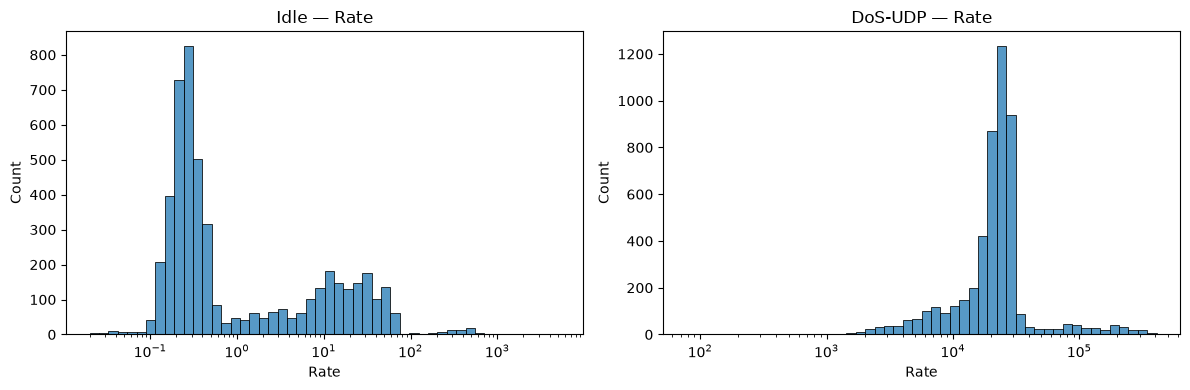

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(idle["Rate"], bins=50, ax=axes[0], log_scale=True)
axes[0].set_title("Idle — Rate")
sns.histplot(attack["Rate"], bins=50, ax=axes[1], log_scale=True)
axes[1].set_title("DoS-UDP — Rate")
plt.tight_layout()

In [41]:
prof_path = PROFILING_DIR / "Idle.pcap.csv"
attack_path = ATTACKS_TRAIN / "TCP_IP-DoS-UDP1_train.pcap.csv"

prof_cols = pd.read_csv(prof_path, nrows=0).columns
attack_cols = pd.read_csv(attack_path, nrows=0).columns

prof_cols.equals(attack_cols)

True

In [42]:
df_prof = pd.read_csv(prof_path, nrows=1000)
df_attack = pd.read_csv(attack_path, nrows=1000)

schema = pd.DataFrame({
    "prof_dtype": df_prof.dtypes,
    "attack_dtype": df_attack.dtypes,
})
schema["dtype_match"] = schema["prof_dtype"] == schema["attack_dtype"]
schema[schema["dtype_match"] == False]  # rows where types differ

,prof_dtype,attack_dtype,dtype_match


In [44]:
def get_columns(path: Path) -> set:
    return set(pd.read_csv(path, nrows=0).columns)
prof_schemas = {p.name: get_columns(p) for p in PROFILING_DIR.glob("*.csv")}
attack_schemas = {p.name: get_columns(p) for p in ATTACKS_TRAIN.glob("*.csv")}
reference = get_columns(prof_path)
mismatched_prof = [name for name, cols in prof_schemas.items() if cols != reference]
mismatched_attack = [name for name, cols in attack_schemas.items() if cols != reference]
mismatched_prof, mismatched_attack

([], [])